In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as scipy
from scipy.optimize import minimize
from scipy.signal import savgol_filter
from scipy.stats import linregress

# Import the csv dataset for 7-day running mean of warmest daily temperatures:
# ----------------------------------------------------------------------------
filename='../../../Data-for-teaching-staff/Forest-fires/van-Oldenborgh-etal-2020/iawap_tmax_-1_max_50_7v_mask0_5lan_su.dat'
dataset = pd.read_csv(filename,delim_whitespace=True,na_values='NaN',comment='#',header=None)
data = np.asarray(dataset.iloc[:, :].values)

years=1.0*data[:,0]
TX7x=1.0*data[:,1]


# Import the csv dataset for GIS GMST:
# ------------------------------------
filename='../../../Data-for-teaching-staff/Forest-fires/van-Oldenborgh-etal-2020/GIS_GMST_annual.csv'
dataset = pd.read_csv(filename,na_values='NaN',comment='#',header=3)
data = np.asarray(dataset.iloc[:, :].values)

years_GMST=1.0*data[:,0]
GMST=1.0*data[:,1]

# calculate slowly varying/ running GMST:
GMST_smoothed = savgol_filter(GMST, 21, 3) # parameters are window size, polynomial order, e.g.,  21, 4

# restrict GMST time series to years in which TX7x is available:
GMST_smoothed=1.0*GMST_smoothed[years_GMST>=years[0]]
years_GMST=1.0*years_GMST[years_GMST>=years[0]]

print("done.")

done.


p= 4.310559276135241e-05 specifying p<0.001.


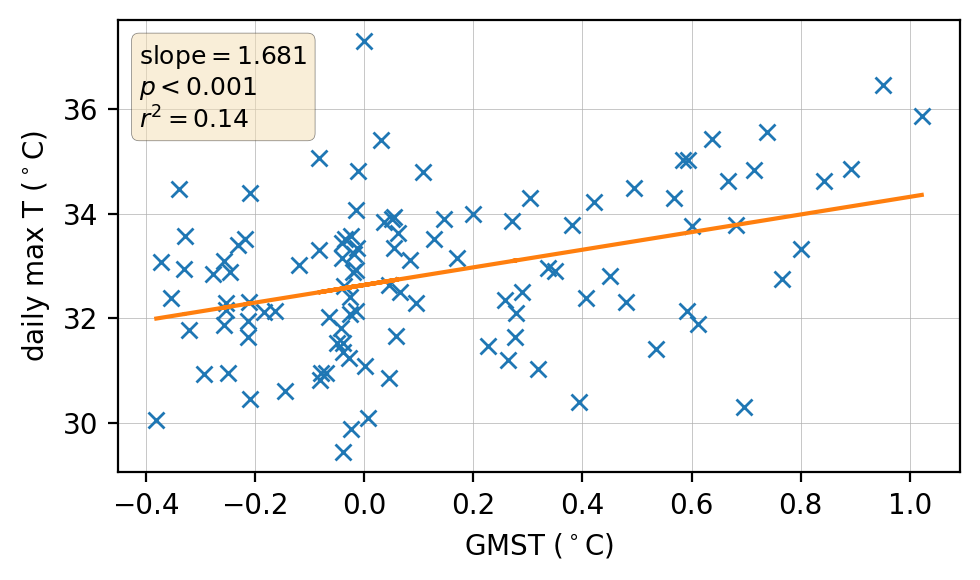

In [2]:
# calculate and plot a linear regression of the TX7x vs GMST

# Fit a regression line to the TX7x-GMST relation:
# ------------------------------------------------
x=1.0*GMST_smoothed; y=1.0*TX7x
fit=linregress(x, y)
slope=fit.slope;
intercept=fit.intercept;
p=fit.pvalue;
r2=(fit.rvalue)**2
regression_line=GMST_smoothed*slope+intercept

plt.figure(figsize=(5,3),dpi=200)
plt.plot(GMST_smoothed,TX7x,"x")
plt.plot(GMST_smoothed,regression_line,"-")
plt.grid(lw=0.25)
plt.xlabel("GMST ($^\circ$C)")
plt.ylabel("daily max T ($^\circ$C)")

# place a text box in upper left in axes coords
ax=plt.gca()
print("p=",p,"specifying p<0.001.")
pmax=np.maximum(p,0.001)
textstr = '\n'.join((
    r'slope$=%.3f$' % (slope,),
    r'$p<%.3f$' % (pmax, ),
    r'$r^2=%.2f$' % (r2, ) ))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5, linewidth=0.25)
ax.text(0.025, 0.95, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)


plt.tight_layout()
plt.show();

/Applications/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: RuntimeWarning: divide by zero encountered in true_divide
  app.launch_new_instance()


Optimization terminated successfully.
         Current function value: 0.000103
         Iterations: 24
         Function evaluations: 150
         Gradient evaluations: 25



Optimization done. cost= 0.00010256759824436176 , fit_TX7x.success= True , fit_TX7x.status= 0
mu0= 32.79903321514744 ,xi= -0.29428 ,alpha= -0.0005042889489676608 ,sigma= 2.146168194429886


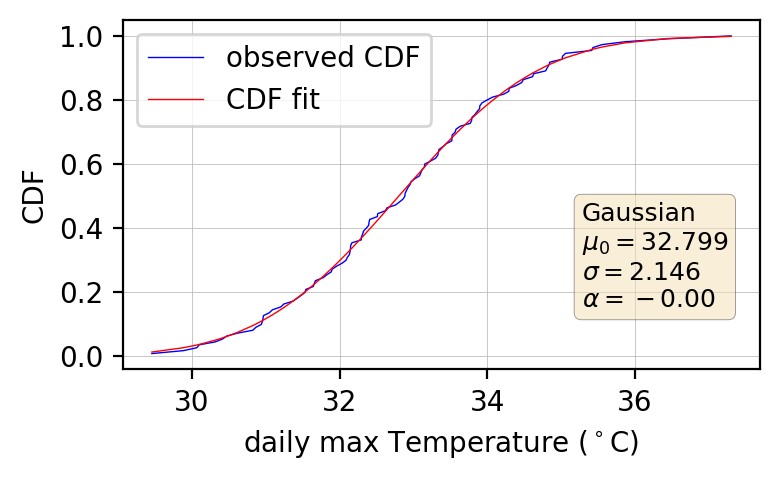

In [7]:
# calculate a histogram with the pdf of the data:
out=np.histogram(TX7x,bins=150)
PDF=out[0]/len(years)
T=out[1]
TT=(T[0:-1]+T[1:])/2

# cumulative pdf, evaluated at the temperatures points in the data set:
# Start by sorting the annual values of daily max temperatures (TX7x) from cool to hot, 
# and then sort the GMST_smoothed so that the sorted series is organized by year like the TX7x data.
I=np.argsort(TX7x)
TX7x_sorted=1.0*TX7x[I]
GMST_smoothed_sorted=1.0*GMST_smoothed[I]
# now calculate CDF: probability of being above a given temperature:
CDF_obs = np.cumsum(TX7x_sorted*0+1)/len(TX7x_sorted)
# calculate return time from probability:
return_time=1.0/(1.0-CDF_obs)


# Fit GEV or gaussian distribution with time-dependent parameters to 7-day
# averaged temp maximum time series:
def fit_CDF_TX7x(T,mu0,xi,alpha,sigma,Tmean):
    """ This is the GEV/ Gaussian CDF, see wikipedia """
    mu=mu0+alpha*Tmean
    if do_GEV_fit:
        exp_arg = -np.maximum(0,(1+xi*(T-mu)/sigma))**(-1/xi)
        CDF=np.exp( exp_arg )
    else:
        CDF=0.5*(1+scipy.special.erf( (T-mu)/sigma ) )
    return np.asarray(CDF)


# cost function to be minimized for the fit:
def cost_TX7x(x,GMST_smoothed):
    """ The cost function to be minimized, the sum of squared 
        differences between the observed and fitted CDFs
    """
    mu0=x[0]
    xi=x[1]
    alpha=x[2]
    sigma=x[3]
    # evalute fit CDF at values given by the data
    CDF_fit=TX7x_sorted*0.0
    Ne=len(CDF_fit)
    Ns=0  #int(3*Ne/4)
    for i in range(Ns,Ne):
        T=1.0*TX7x_sorted[i]
        Tmean=1.0*GMST_smoothed_sorted[i]
        CDF_fit[i]=fit_CDF_TX7x(T,mu0,xi,alpha,sigma,Tmean)
    # quadratic cost:
    cost=np.sum((CDF_fit[Ns:Ne]-CDF_obs[Ns:Ne])**2)/(Ne-Ns)
    # cross entropy cost:
    #x=1.0*CDF_fit[Ns:Ne]; y=1.0*CDF_obs[Ns:Ne]; y[y<1.e-6]=1.e-6; x[x<1.e-6]=1.e-6; cost=-np.sum( y*np.log(x)+(1-y)*np.log(1-x) )/(Ne-Ns)

    if 0:
        plt.figure(1);
        plt.clf()
        plt.plot(TX7x_sorted,CDF_obs,"-+",label="CDF obs")
        plt.plot(TX7x_sorted,CDF_fit,"-x",label="CDF  fit")
        plt.legend()
        #plt.show()
        plt.pause(0.01)
    #print(cost)
    return cost


# which fit to use?
do_GEV_fit=False # if false, fit to a Gaussian (error function CDF)

# initial guess for fitted distribution parameters:
mu0=32.2793
xi=-0.29428
alpha=0.007
sigma=1.4884
x0=(mu0,xi,alpha,sigma)
# perform minimization
fit_TX7x=minimize(cost_TX7x, x0, args=(GMST_smoothed), tol=1.0e-6, method='BFGS'
                  ,options={'disp': True})

# get solution of minimization:
x=fit_TX7x.x
mu0=x[0]
xi=x[1]
alpha=x[2]
sigma=x[3]


# use parameters from from 
# Data-for-teaching-staff/Forest-fires/van-Oldenborgh-etal-2020/heat-results/fit_max7_DJF_tmax_awap.html:
if 0:
    print("\n\n\n********************************************************************")
    print("*** using prescribed GEV values, not solution from optimization!! **")
    print("********************************************************************")
    mu0=31.885
    xi=-0.209
    alpha=0*1.531
    sigma=1.359

# print it:
print("\n\n\nOptimization done. cost=",fit_TX7x.fun
      ,", fit_TX7x.success=",fit_TX7x.success
      ,", fit_TX7x.status=",fit_TX7x.status);
print("mu0=",mu0,",xi=",xi,",alpha=",alpha,",sigma=",sigma)

# calculate and plot optimal distribution after fit:
CDF_fit=TX7x*0.0
for i in range(len(CDF_fit)):
    T=1.0*TX7x_sorted[i]
    Tmean=1.0*GMST_smoothed_sorted[i]
    CDF_fit[i]=fit_CDF_TX7x(T,mu0,xi,alpha,sigma,Tmean)

fig=plt.figure(figsize=(4,2.5),dpi=200);
plt.clf()
plt.plot(TX7x_sorted,CDF_obs,"-",lw=0.5,color="b",markersize=4,markeredgewidth=0.5,label="observed CDF")
plt.plot(TX7x_sorted,CDF_fit,"-",lw=0.5,color="r",markersize=2,markeredgewidth=0.5,label="CDF fit")
plt.xlabel("daily max Temperature ($^\circ$C)")
plt.ylabel("CDF")
plt.legend(loc="upper left")
plt.grid(lw=0.25)

# place a text box with some info in bottm right in axes coords
ax=plt.gca()
if do_GEV_fit:
    title="GEV"
else:
    title="Gaussian"
textstr = '\n'.join((
    r'%s' % (title,),
    r'$\mu_0=%.3f$' % (mu0,),
    r'$\sigma=%.3f$' % (sigma, ),
    r'$\alpha=%.2f$' % (alpha, ) ))
if do_GEV_fit:
    title="GEV"
    textstr=textstr+"\n$\\xi=%.3f$" % (xi, )
else:
    title="Gaussian"
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5, linewidth=0.25)
ax.text(0.72, 0.48, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)


# finalize plot:
plt.tight_layout()
plt.show();
fig.savefig("Output/forest-fires-vanOldenborgh-CDF-fit.pdf");

/Applications/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:38: RuntimeWarning: divide by zero encountered in true_divide
/Applications/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:39: RuntimeWarning: divide by zero encountered in true_divide


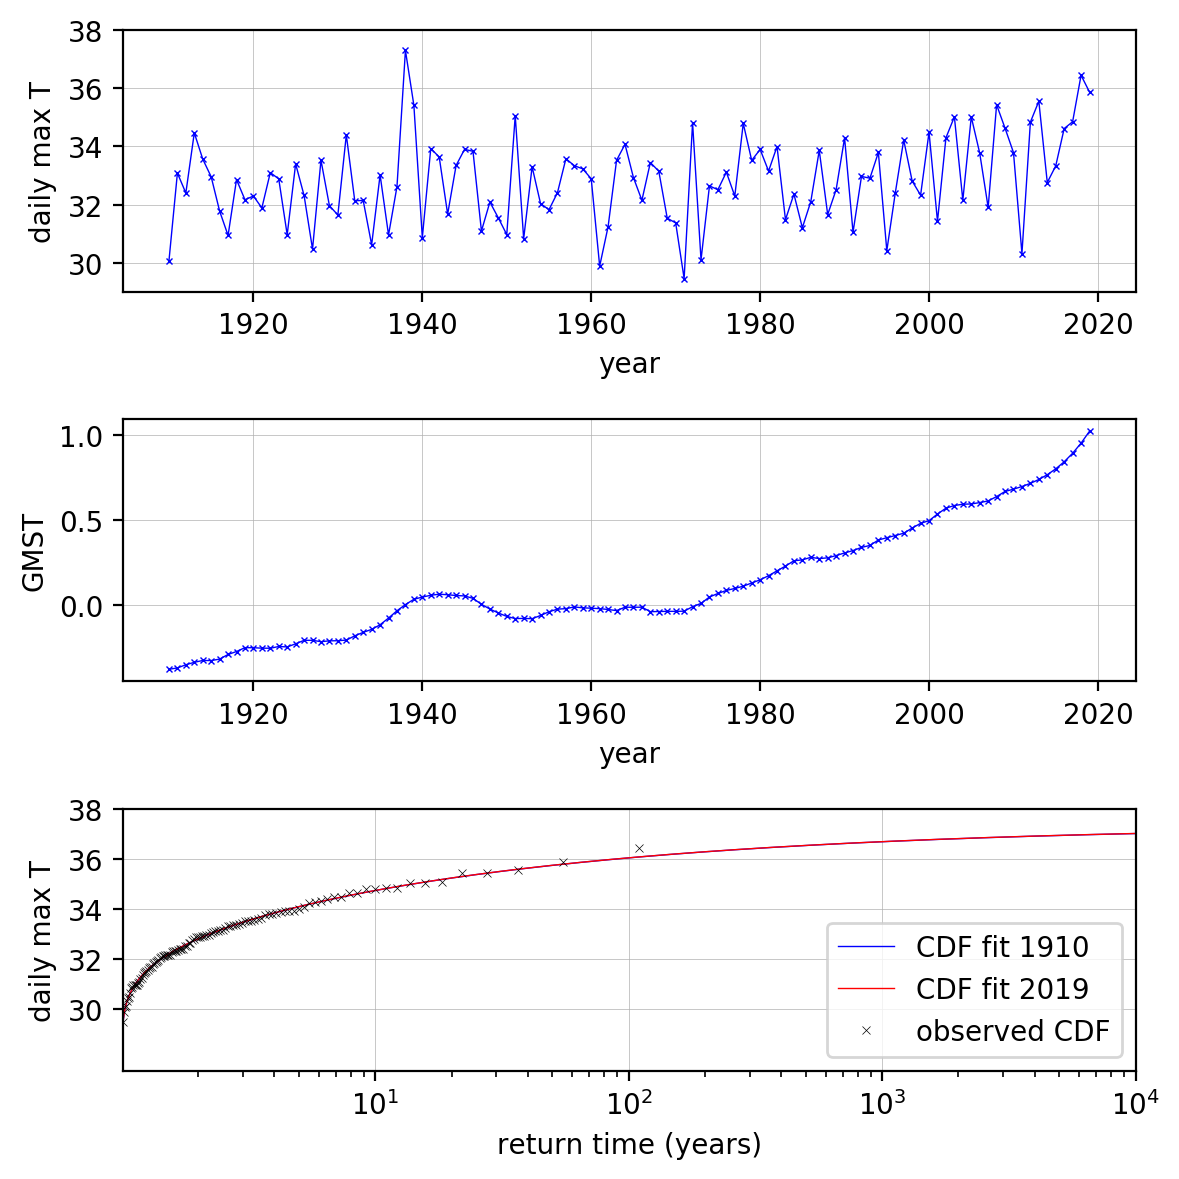

In [4]:
# ------------------------------------------------------------------
# plots
# ------------------------------------------------------------------

fig=plt.figure(figsize=(6,6),dpi=200)

# plot 7-day averaged maximum daily time series:
plt.subplot(3,1,1)
plt.plot(years,TX7x,lw=0.5,color="b")
plt.plot(years,TX7x,"x",color="b",markersize=2,markeredgewidth=0.5)
plt.ylabel("daily max T")
plt.xlabel("year")
plt.yticks(np.arange(30,40,2))
plt.ylim(29,38)
plt.grid(lw=0.25)

# plot GMST:
plt.subplot(3,1,2)
plt.plot(years_GMST,GMST_smoothed,lw=0.5,color="b")
plt.plot(years_GMST,GMST_smoothed,"x",color="b",markersize=2,markeredgewidth=0.5)
plt.ylabel("GMST")
plt.xlabel("year")
#plt.yticks(np.arange(30,40,2))
#plt.ylim(29,38)
plt.grid(lw=0.25)

# plot CDFs: observed vs fitted, following Fig 4 of Van Oldernborgh:
# first calculate fitted CDF for 1910 and 2018:
Taxis=np.arange(28,38,0.01)
CDF1910=Taxis*0.0
CDF2019=Taxis*0.0
for i in range(len(Taxis)):
    T=1.0*Taxis[i]
    Tmean=1.0*GMST_smoothed[0]
    CDF1910[i]=fit_CDF_TX7x(T,mu0,xi,alpha,sigma,Tmean)
    Tmean=1.0*GMST_smoothed[-1]
    CDF2019[i]=fit_CDF_TX7x(T,mu0,xi,alpha,sigma,Tmean)
return_time1910=1/(1-CDF1910)
return_time2019=1/(1-CDF2019)

# then plot the CDFs:
plt.subplot(3,1,3)
#plt.semilogx(return_time,TX7x_sorted,color="k",linewidth=0.5)
plt.semilogx(return_time1910,Taxis,"-",lw=0.5,color="b",label="CDF fit 1910")
plt.semilogx(return_time2019,Taxis,"-",lw=0.5,color="r",label="CDF fit 2019")
plt.semilogx(return_time,TX7x_sorted,"x",color="k",markersize=3,markeredgewidth=0.25,label="observed CDF")
plt.ylabel("daily max T")
plt.xlabel("return time (years)")
plt.xlim(1.01,10000)
plt.yticks(np.arange(30,40,2))
#plt.ylim(29,38)
plt.grid(lw=0.25)
plt.legend()


# finalize plot:
plt.tight_layout()
plt.show();
fig.savefig("Output/forest-fires-vanOldenborgh-TX7x.pdf");